# **Activity 1: Building the Data Processing Pipeline - Group 3**

**Group members:**
- Abdullah Ali Saleem
- Danil Seksenov
- Nikita Soo
- Fatih Özdil

##**Part 0: Introduction and Setup**

**1. What is Supervised Learning?**

---

Supervised learning is a type of machine learning where an algorithm learns from labeled data. This means the training data includes both input features and the corresponding correct output values, allowing the model to learn a mapping function from input to output.

**2. The Standard Machine Learning Pipeline**

---

Most supervised learning projects follow a standardized workflow. Regardless of whether you are predicting spam emails or house prices, you will generally follow these 7 steps:

1. Load data
2. Explore & Preprocess Data
3. Split data
4. Choose & Create Model
5. Train Model
6. Make Predicions
7. Evaluate Model


**3. Datasets We Will Use:**

---

We will explore four different datasets to practice both classification and regression:

- **Titanic (Classification)**
- **Iris (Classification)**
- **Auto MPG (Regression)**
- **Diabetes (Regression)**

**4. Setup:**

---

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import load_iris, load_diabetes
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configure plots for better visibility
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

**Part 0: Knowledge Check**

---

**Question 1: You are building an AI to look at a photo of an X-ray and determine if a bone is Fractured or Not Fractured. Is this a Classification task or a Regression task?**

Answer: This is a Classification task because the AI is determining between discrete categories (Fractured' or Not Fractured).

**Question 2: In the Machine Learning Pipeline, why do we split our data into a "Training Set" and a "Testing Set"? Why not just train the model on all the data we have?**

Answer: Because this way we can ensure that the model will not just memorize answers, but instead model is trying to learn patterns

**Question 3: What exactly is a "Label" (also known as a Target) in Supervised Learning?**

Answer: Its the correct answer attached to the historical data

##**Part 1: Guided Classification (Titanic Dataset)**

Goal: Learn the classification pipeline by predicting passenger survival on the Titanic dataset using a Decision Tree algorithm. We will use a version of the dataset that we lightly clean directly in the code.

**Step 1.1: Load Pre-Cleaned Data**

---





In [2]:
# Load a Titanic dataset directly from a URL
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url_titanic)

# Basic cleanup:
# 1. Drop columns that are unique identifiers or text that a basic model cannot process mathematically.
titanic_df = titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis=1, errors='ignore')

# 2. Fill missing 'Age' values with the median age of all passengers.
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# 3. Convert 'Sex' from text ('male'/'female') to numeric (0/1). This is a simple form of encoding.
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

# 4. Drop any remaining rows that still have missing values (e.g., if 'Fare' was missing).
titanic_df.dropna(inplace=True)

print("Titanic Data (first 5 rows):")
print(titanic_df.head())
print("\nData Info:")
titanic_df.info()

Titanic Data (first 5 rows):
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare
0         0       3    0  22.0      1      0   7.2500
1         1       1    1  38.0      1      0  71.2833
2         1       3    1  26.0      0      0   7.9250
3         1       1    1  35.0      1      0  53.1000
4         0       3    0  35.0      0      0   8.0500

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


/tmp/ipykernel_6618/626608649.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)


**Step 1.2: Define Features (X) and Target (y)**

---

In [3]:
# Define features (X) by dropping the target column
X_titanic = titanic_df.drop('Survived', axis=1)

# Define target (y) by selecting only the target column
y_titanic = titanic_df['Survived']

print("\nFeatures (X):")
print(X_titanic.head(2))
print("\nTarget (y):")
print(y_titanic.head(2))


Features (X):
   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833

Target (y):
0    0
1    1
Name: Survived, dtype: int64


**Step 1.3: Split Data into Training and Testing Sets**

---

In [4]:
# Split the data
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)

print(f"\nTraining set shape: X={X_train_titanic.shape}, y={y_train_titanic.shape}")
print(f"Testing set shape: X={X_test_titanic.shape}, y={y_test_titanic.shape}")


Training set shape: X=(712, 6), y=(712,)
Testing set shape: X=(179, 6), y=(179,)


**Step 1.4: Create and Train a Decision Tree Classifier**

---

In [5]:
# Create a Decision Tree Classifier model
# max_depth restricts how deep the tree can grow to prevent overfitting
clf_titanic = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model using the training data ONLY
clf_titanic.fit(X_train_titanic, y_train_titanic)

print("\nDecision Tree Classifier model trained successfully.")


Decision Tree Classifier model trained successfully.


**Step 1.5: Make Predictions on Test Data**

---

In [6]:
# Make predictions
y_pred_titanic = clf_titanic.predict(X_test_titanic)

# Display first 10 predictions vs actual values
print("\nFirst 10 Predictions:", y_pred_titanic[:10])
print("First 10 Actual Values:", y_test_titanic[:10].values)


First 10 Predictions: [0 0 0 0 0 0 1 1 0 0]
First 10 Actual Values: [0 0 1 0 1 1 1 0 0 0]


**Step 1.6: Evaluate the Model**

---

In [7]:
# Evaluate the model
accuracy_titanic = accuracy_score(y_test_titanic, y_pred_titanic)
print(f"\nModel Accuracy: {accuracy_titanic:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_titanic, y_pred_titanic, target_names=['Did not Survive', 'Survived']))


Model Accuracy: 0.7542

Classification Report:
                 precision    recall  f1-score   support

Did not Survive       0.76      0.88      0.82       110
       Survived       0.75      0.55      0.63        69

       accuracy                           0.75       179
      macro avg       0.75      0.72      0.72       179
   weighted avg       0.75      0.75      0.75       179



**Step 1.7: Visualize the Decision Tree (Optional)**

---

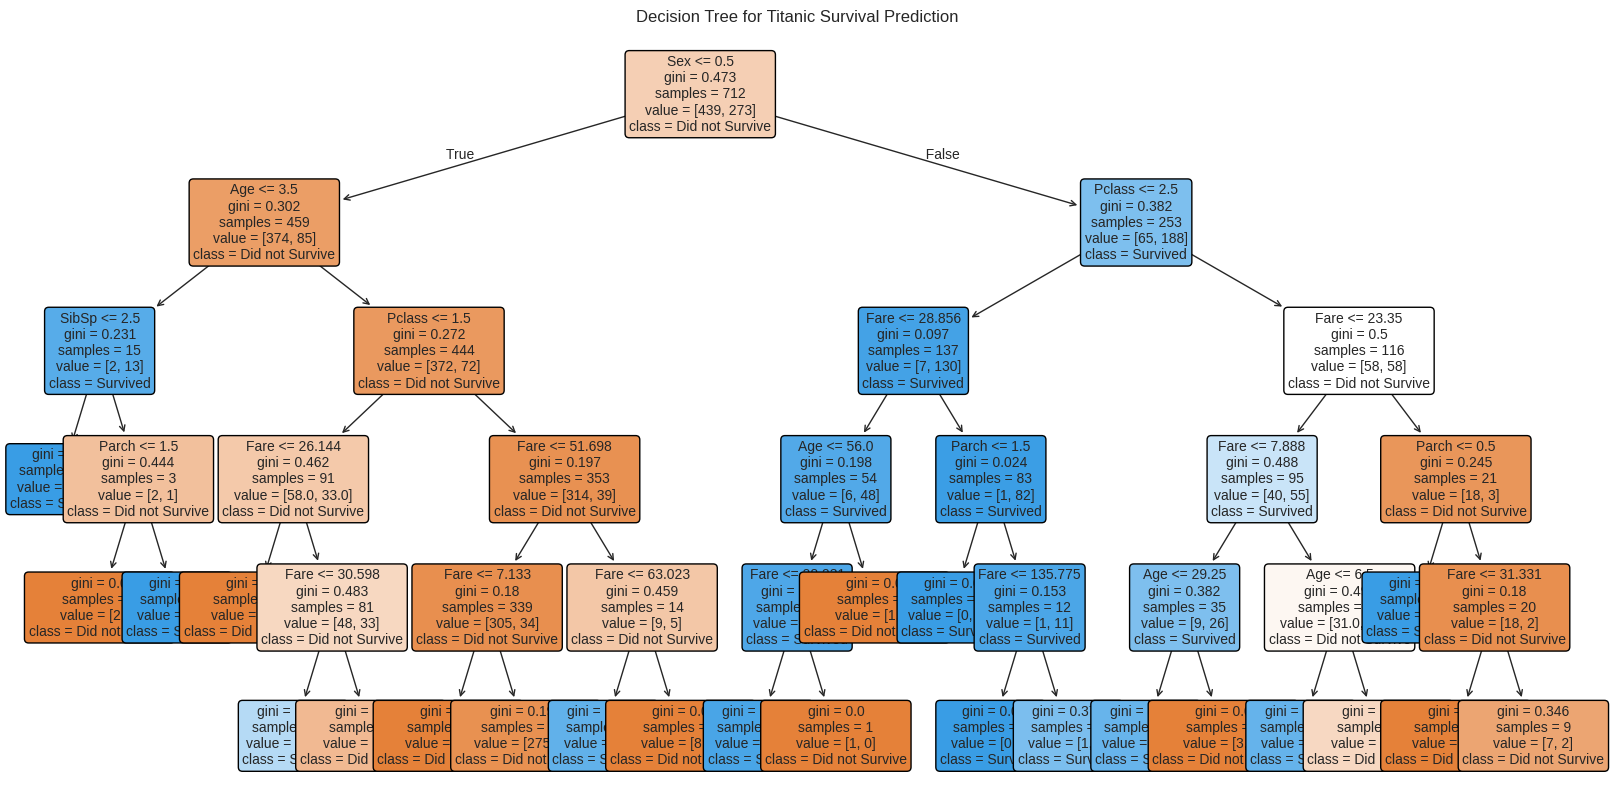

In [8]:
# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(clf_titanic,
          feature_names=X_titanic.columns,
          class_names=['Did not Survive', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()

**Knowledge Check (Part 1)**

---

**Question 1: The Flaw of Accuracy Why is overall "Accuracy" not always a reliable metric for evaluating classification models? Provide a hypothetical example where a high accuracy score can be misleading, and explain why precision or recall would be more important.**

Answer: Accuracy can be misleading with imbalanced datasets. For example, if 95% of emails are not spam, a model that always predicts "not spam" would have 95% accuracy but catch zero spam emails.

**Question 2: Confusion Matrix What is a confusion matrix in classification? Describe its four main components and explain how it helps assess a classifier's performance better than a single accuracy number.**

Answer: 1. True Positive, True Negative, False Positives, False Negatives

**Question 3: Why Precision, Recall, and F1 Score Matter in Medical Diagnosis In medical diagnoses, why are precision and recall not always enough, and how does the F1 score provide a better evaluation metric? Explain with an example.**

Answer: n medical diagnosis, both high precision (avoiding false alarms) and high recall (not missing actual cases) are critical. However, they can conflict. The F1-score is a better evaluation metric because it balances both precision and recall, providing a single score that reflects a model's effectiveness when both false positives and false negatives are costly.

**Question 4: Why is Median Preferred Over Average for Filling Missing Values? In the context of filling missing values, why is the median often preferred over the average (mean)? What could go wrong if we used the average instead of the median in situations like filling missing 'Age' values in a dataset?**

Answer: The median is preferred over the average (mean) for filling missing values because it is more robust to outliers.

##**Part 2: Practice Classification (Iris Dataset)**

**Step 2.1: Load Iris Data**

---

In [9]:
# Load the Iris dataset directly from sklearn
iris = load_iris()

# The sklearn dataset comes as a dictionary-like object.
# We need to format it into a Pandas DataFrame for easier viewing.
iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                       columns=iris['feature_names'] + ['target'])

# Map the numeric target (0, 1, 2) to actual species names for human readability
iris_df['species'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Iris Data (first 5 rows):")
print(iris_df.head())
print("\nData Info:")
iris_df.info()

Iris Data (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0     0.0  setosa  
1     0.0  setosa  
2     0.0  setosa  
3     0.0  setosa  
4     0.0  setosa  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)  

**Step 2.2: Define Features (X) and Target (y)**

---

In [10]:
# Define X_iris (features) and y_iris (target)
# We MUST drop both the 'target' column and the 'species' column to prevent the model from cheating!
X_iris = iris_df.drop(['target', 'species'], axis=1)
y_iris = iris_df['target']

# Print shapes to verify
print(f"\nIris features shape: {X_iris.shape}")
print(f"Iris target shape: {y_iris.shape}")


Iris features shape: (150, 4)
Iris target shape: (150,)


**Step 2.3: Split Data**

---

In [11]:
# Split the data into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Print shapes to verify
print(f"\nTraining set shape: X={X_train_iris.shape}, y={y_train_iris.shape}")
print(f"Testing set shape: X={X_test_iris.shape}, y={y_test_iris.shape}")


Training set shape: X=(120, 4), y=(120,)
Testing set shape: X=(30, 4), y=(30,)


**Step 2.4: Create and Train a Decision Tree Classifier**

---

In [12]:
# Create and train the model
clf_iris = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_iris.fit(X_train_iris, y_train_iris)

print("\nIris Decision Tree model trained.")


Iris Decision Tree model trained.


**Step 2.5: Make Predictions**

---

In [13]:
# Make predictions on the unseen testing features
y_pred_iris = clf_iris.predict(X_test_iris)

# Display first 10 predictions vs actual values
print("\nFirst 10 Predictions:", y_pred_iris[:10])
print("First 10 Actual Values:", y_test_iris[:10].values)


First 10 Predictions: [0. 2. 1. 1. 0. 1. 0. 0. 2. 1.]
First 10 Actual Values: [0. 2. 1. 1. 0. 1. 0. 0. 2. 1.]


**Step 2.6: Evaluate the Model**

---

In [14]:
# Evaluate the model
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
print(f"\nIris Model Accuracy: {accuracy_iris:.4f}")

# Print the classification report
print("\nIris Classification Report:")
print(classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names))


Iris Model Accuracy: 0.9333

Iris Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



**Knowledge Check (Part 2)**

---

**Question 1: Data Leakage In Step 2.2, the code explicitly drops both the target column and the species column from the X (Features) dataframe. What would happen if we forgot to drop the species column, and passed it into the model as a feature?**

Answer: The massive error "Data Leakage" would appear

**Question 2: Binary vs. Multi-class Classification In Part 1 (Titanic), the target was "Survived" or "Did Not Survive" (2 options). In Part 2 (Iris), the target is "Setosa", "Versicolor", or "Virginica" (3 options). How does the Classification Report handle this difference?**

Answer: The Iris dataset is a Multi-class Classification problem. The Titanic dataset was a Binary Classification problem

**Question 3: Dataset Complexity Compare the accuracy scores you received on the Titanic model versus the Iris model. Why does the Iris model perform so much better?**

Answer: Iris model achieves almost perfect result 95-100% and the titanic model is around 80%. This happens of two reasons: 1. Predictability and 2. Cleanliness

##**Part 3: Guided Regression (Auto MPG Dataset)**

**Step 3.1: Load Pre-Cleaned Auto MPG Data**

---

In [15]:
# Load pre-cleaned Auto MPG dataset
url_mpg = "https://raw.githubusercontent.com/ML-Course-2026/session3/refs/heads/main/datasets/cars/auto-mpg.csv"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

# The na_values="?" parameter tells Pandas to treat "?" as a missing value (NaN)
mpg_df = pd.read_csv(url_mpg, names=column_names, na_values="?", header=0)

# Basic Cleaning (We will dive much deeper into this in Part 5)
# 1. Drop the car name because it is a text identifier, not a mathematical feature.
mpg_df = mpg_df.drop('car_name', axis=1)

# 2. Fill missing horsepower values with the median.
mpg_df['horsepower'].fillna(mpg_df['horsepower'].median(), inplace=True)

# 3. Drop 'origin' for now. It is a category (1=USA, 2=Europe, 3=Japan), but
# treating it as a raw number confuses the model. We will fix this properly in Part 5.
mpg_df = mpg_df.drop('origin', axis=1)

# Drop any remaining rows with missing data
mpg_df.dropna(inplace=True)

print("Auto MPG Data (first 5 rows):")
print(mpg_df.head())
print("\nData Info:")
mpg_df.info()

Auto MPG Data (first 5 rows):
    mpg  cylinders  displacement  horsepower  weight  acceleration  model_year
0  18.0          8         307.0       130.0    3504          12.0          70
1  15.0          8         350.0       165.0    3693          11.5          70
2  18.0          8         318.0       150.0    3436          11.0          70
3  16.0          8         304.0       150.0    3433          12.0          70
4  17.0          8         302.0       140.0    3449          10.5          70

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    i

/tmp/ipykernel_6618/1595777749.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mpg_df['horsepower'].fillna(mpg_df['horsepower'].median(), inplace=True)


**Step 3.2: Define Features (X) and Target (y)**

---

In [16]:
# Define features (X) and target (y)
X_mpg = mpg_df.drop('mpg', axis=1)
y_mpg = mpg_df['mpg']

print("\nFeatures (X):")
print(X_mpg.head(2))
print("\nTarget (y):")
print(y_mpg.head(2))


Features (X):
   cylinders  displacement  horsepower  weight  acceleration  model_year
0          8         307.0       130.0    3504          12.0          70
1          8         350.0       165.0    3693          11.5          70

Target (y):
0    18.0
1    15.0
Name: mpg, dtype: float64


**Step 3.3: Split Data**

---

In [17]:
# Split the data
X_train_mpg, X_test_mpg, y_train_mpg, y_test_mpg = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42
)

print(f"\nTraining set shape: X={X_train_mpg.shape}, y={y_train_mpg.shape}")
print(f"Testing set shape: X={X_test_mpg.shape}, y={y_test_mpg.shape}")


Training set shape: X=(318, 6), y=(318,)
Testing set shape: X=(80, 6), y=(80,)


**Step 3.4: Create and Train a Linear Regression Model**

---

In [18]:
# Create a Linear Regression model
lr_mpg = LinearRegression()

# Train the model on the training data
lr_mpg.fit(X_train_mpg, y_train_mpg)

print("\nLinear Regression model trained successfully.")


Linear Regression model trained successfully.


**Step 3.5: Make Predictions on Test Data**

---

In [19]:
# Make predictions
y_pred_mpg = lr_mpg.predict(X_test_mpg)

# Display first 5 predictions vs actual values
print("\nFirst 5 Predictions:", y_pred_mpg[:5])
print("First 5 Actual Values:", y_test_mpg[:5].values)


First 5 Predictions: [31.53042525 30.71093633 21.75965091 17.00444007 12.61316451]
First 5 Actual Values: [33. 28. 19. 13. 14.]


**Step 3.6: Evaluate the Model**

---

In [20]:
# Evaluate the model
mae_mpg = mean_absolute_error(y_test_mpg, y_pred_mpg)
mse_mpg = mean_squared_error(y_test_mpg, y_pred_mpg)
rmse_mpg = np.sqrt(mse_mpg) # We calculate RMSE by taking the square root of MSE
r2_mpg = r2_score(y_test_mpg, y_pred_mpg)

print(f"\nMean Absolute Error (MAE): {mae_mpg:.4f}")
print(f"Mean Squared Error (MSE): {mse_mpg:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_mpg:.4f}")
print(f"R-squared (R²): {r2_mpg:.4f}")


Mean Absolute Error (MAE): 2.4668
Mean Squared Error (MSE): 9.4401
Root Mean Squared Error (RMSE): 3.0725
R-squared (R²): 0.8244


**Step 3.7: Visualize Predictions vs Actuals**

---

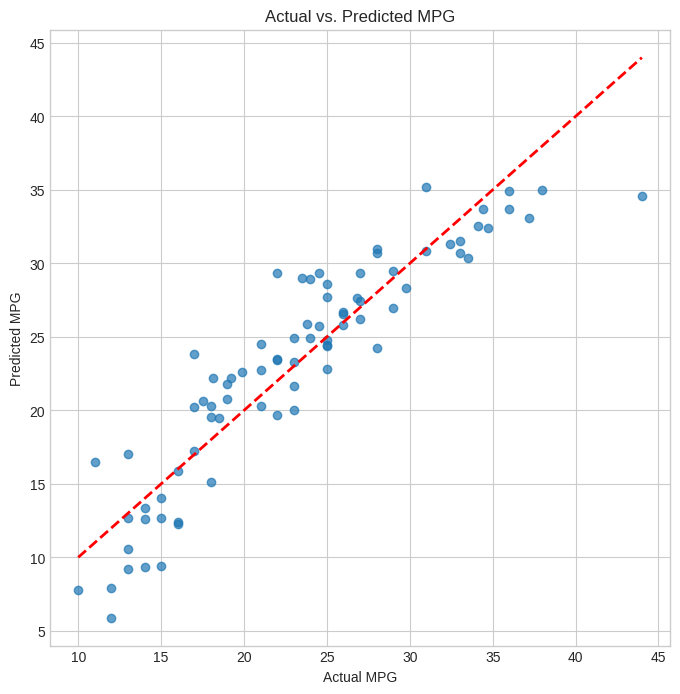

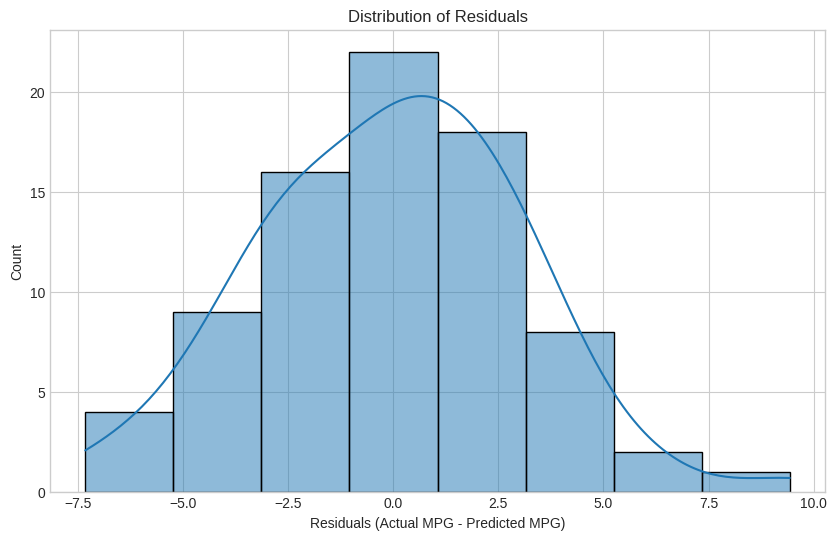

In [21]:
# Plot Actual vs Predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test_mpg, y_pred_mpg, alpha=0.7)

# Draw a red dashed line representing "Perfect Prediction"
plt.plot([y_test_mpg.min(), y_test_mpg.max()], [y_test_mpg.min(), y_test_mpg.max()], '--r', linewidth=2)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs. Predicted MPG')
plt.show()

# Plot Residuals (The Errors)
residuals_mpg = y_test_mpg - y_pred_mpg
plt.figure(figsize=(10, 6))
sns.histplot(residuals_mpg, kde=True)
plt.xlabel('Residuals (Actual MPG - Predicted MPG)')
plt.title('Distribution of Residuals')
plt.show()

**Knowledge Check (Part 3)**

---

**Question 1: The Accuracy Trap If you try to run the code accuracy_score(y_test_mpg, y_pred_mpg) on this model, Python will throw a massive error and crash. Why?**

Answer: Accuracy_score is for classification, which compares discrete categories. y_test_mpg and y_pred_mpg are continuous values (regression), leading to a type mismatch error when trying to use this metric.

**Question 2: MAE vs RMSE Imagine you have a model predicting housing prices. The MAE is $10,000, but the RMSE is $50,000. Why would the RMSE be so much higher than the MAE, and what does this tell you about the model's performance?**

Answer: RMSE (Root Mean Squared Error) penalizes larger errors more heavily than MAE (Mean Absolute Error) due to squaring. A much higher RMSE indicates the model has significant large errors

**Question 3: Missing Values In Step 3.1, we filled the missing horsepower values with the median horsepower of the entire dataset. Why did we use the median instead of simply filling the missing spaces with 0?**

Answer: Filling with 0 would imply an unrealistic 0 horsepower, which would severely skew the data and mislead the model.

**Question 4: Why Is Stratification Not Used in Regression? Why did we not use stratify=y_mpg in the regression example (e.g., predicting MPG) like we did in the classification examples (e.g., Iris, Titanic datasets)? Explain why stratification doesn't apply in the context of regression.**

Answer: Stratification is used to maintain class proportions in classification tasks (discrete categories). In regression, the target variable (like MPG) is continuous

##**Part 4: Practice Regression (Diabetes Dataset)**

**Step 4.1: Load Diabetes Data**

---

In [22]:
# Load the Diabetes dataset
diabetes = load_diabetes()
diabetes_df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)

# Add the target column to the dataframe
diabetes_df['target'] = diabetes.target

print("Diabetes Data (first 5 rows):")
print(diabetes_df.head())
print("\nData Info:")
diabetes_df.info()

Diabetes Data (first 5 rows):
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2

**Step 4.2: Define Features (X) and Target (y)**

---

In [23]:
# Define X_diabetes and y_diabetes
X_diabetes = diabetes_df.drop('target', axis=1)
y_diabetes = diabetes_df['target']

# Print shapes to verify
print(f"\nDiabetes features shape: {X_diabetes.shape}")
print(f"Diabetes target shape: {y_diabetes.shape}")


Diabetes features shape: (442, 10)
Diabetes target shape: (442,)


**Step 4.3: Split Data**

---

In [24]:
# Split the data into X_train, X_test, y_train, y_test
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# Print shapes to verify
print(f"\nTraining set shape: X={X_train_diabetes.shape}, y={y_train_diabetes.shape}")
print(f"Testing set shape: X={X_test_diabetes.shape}, y={y_test_diabetes.shape}")


Training set shape: X=(353, 10), y=(353,)
Testing set shape: X=(89, 10), y=(89,)


**Step 4.4: Create and Train a Linear Regression Model**

---

In [25]:
# Create and train the model
lr_diabetes = LinearRegression()
lr_diabetes.fit(X_train_diabetes, y_train_diabetes)

print("\nDiabetes Linear Regression model trained.")


Diabetes Linear Regression model trained.


**Step 4.5: Make Predictions**

---

In [26]:
# Make predictions
y_pred_diabetes = lr_diabetes.predict(X_test_diabetes)

# Display first 5 predictions vs actual values
print("\nFirst 5 Predictions:", y_pred_diabetes[:5])
print("First 5 Actual Values:", y_test_diabetes[:5].values)


First 5 Predictions: [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]
First 5 Actual Values: [219.  70. 202. 230. 111.]


**Step 4.6: Evaluate the Model**

---

In [27]:
# Evaluate the model
mae_diabetes = mean_absolute_error(y_test_diabetes, y_pred_diabetes)
mse_diabetes = mean_squared_error(y_test_diabetes, y_pred_diabetes)
rmse_diabetes = np.sqrt(mse_diabetes)
r2_diabetes = r2_score(y_test_diabetes, y_pred_diabetes)

print(f"\nDiabetes Model Evaluation:")
print(f"MAE: {mae_diabetes:.4f}")
print(f"MSE: {mse_diabetes:.4f}")
print(f"RMSE: {rmse_diabetes:.4f}")
print(f"R²: {r2_diabetes:.4f}")


Diabetes Model Evaluation:
MAE: 42.7941
MSE: 2900.1936
RMSE: 53.8534
R²: 0.4526


**Step 4.7: Visualize Predictions vs Actuals**

---

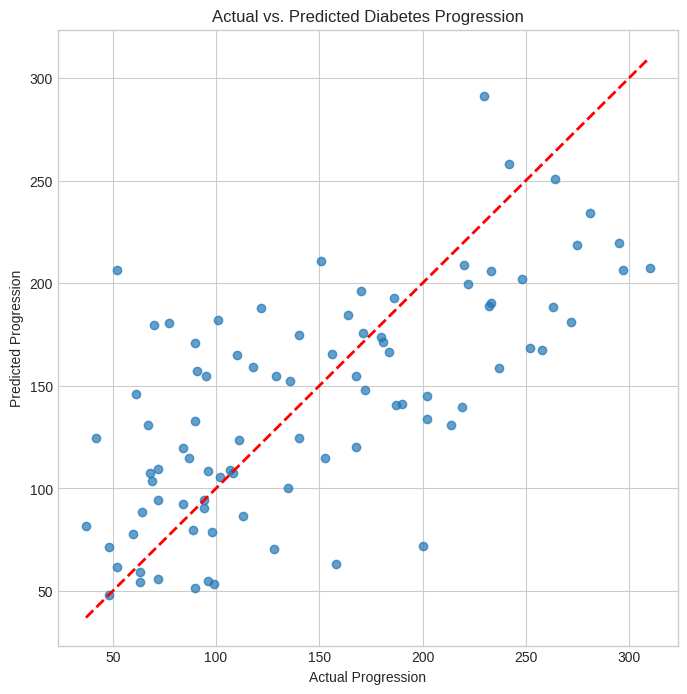

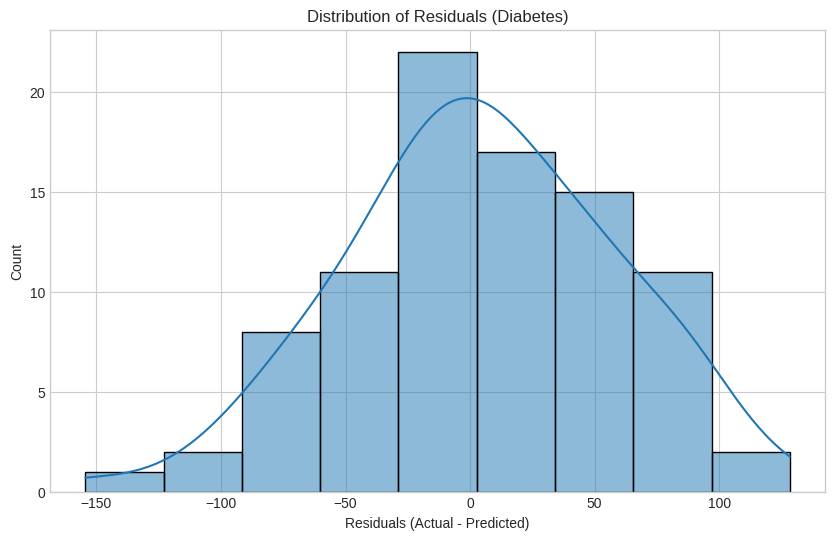

In [28]:
# Plot Actual vs Predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test_diabetes, y_pred_diabetes, alpha=0.7)
plt.plot([y_test_diabetes.min(), y_test_diabetes.max()], [y_test_diabetes.min(), y_test_diabetes.max()], '--r', linewidth=2)
plt.xlabel('Actual Progression')
plt.ylabel('Predicted Progression')
plt.title('Actual vs. Predicted Diabetes Progression')
plt.show()

# Plot Residuals
residuals_diabetes = y_test_diabetes - y_pred_diabetes
plt.figure(figsize=(10, 6))
sns.histplot(residuals_diabetes, kde=True)
plt.xlabel('Residuals (Actual - Predicted)')
plt.title('Distribution of Residuals (Diabetes)')
plt.show()

**Knowledge Check (Part 4)**

---

**Question 1: Interpreting the R-Squared (R²) Score Compare the R² score you received for the Auto MPG model (Part 3) with the R² score for the Diabetes model (Part 4).**

1. Which model performed better?
2. What does a lower R² score tell you about the dataset itself?

Answer: 1. MPG model preformed better. 2. A lower R² score tells you that the features provided to the model (BMI, blood pressure, etc.) are not sufficient to perfectly predict disease progression.

**Question 2: Making Sense of the MAE In Step 4.6, you printed the Mean Absolute Error (MAE). If the MAE is roughly 42.7, how do you explain that number to a doctor who has no background in data science?**

Asnwer: An MAE of 42.7 means that, on average, our model's prediction for a patient's diabetes progression score will be off by about 43 points, either higher or lower

**Question 3: Examining the Scatter Plot Look closely at the first chart generated in Step 4.7 (Actual vs. Predicted). Notice that as the Actual Progression (the x-axis) gets higher, the blue dots tend to fall below the red dashed line. What does this indicate about the model's behavior?**

Answer: When dots fall below the red line of perfect prediction, it means the model is underpredicting.



##**Part 5: The Reality - Data Preprocessing**

**Step 5.1: Load RAW Data and Initial Inspection Notice the na_values='?': this tells pandas to treat '?' as missing.**

---

In [29]:
import pandas as pd

# Load the raw data again
url_mpg = "https://raw.githubusercontent.com/ML-Course-2026/session3/main/datasets/cars/auto-mpg.csv"

# Define column names (to ensure consistency)
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

# Read CSV correctly (comma-separated)
raw_mpg_df = pd.read_csv(url_mpg, names=column_names, na_values="?", header=0)

# Display first rows
print("Raw Auto MPG Data (first 5 rows):")
print(raw_mpg_df.head())

# Data info
print("\nRaw Data Info:")
raw_mpg_df.info()

# Check for missing values
print("\nMissing values count:")
print(raw_mpg_df.isnull().sum())

Raw Auto MPG Data (first 5 rows):
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

Raw Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null  

**Step 5.2: Handling Missing Values (Imputation) We need to fill or remove missing values. For horsepower, let's fill with the median.**

---

In [32]:
# Calculate median horsepower (ignoring NaNs)
median_hp = raw_mpg_df['horsepower'].median()
print(f"\nMedian horsepower: {median_hp}")

# Fill missing horsepower values
raw_mpg_df['horsepower'].fillna(median_hp, inplace=True)

# Verify missing values are handled
print("\nMissing values count after imputation:")
print(raw_mpg_df.isnull().sum())


Median horsepower: 93.5

Missing values count after imputation:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


/tmp/ipykernel_6618/2724875847.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_mpg_df['horsepower'].fillna(median_hp, inplace=True)


**Step 5.3: Handling Categorical Features (Encoding) origin is categorical. Treating it as a number (1, 2, 3) implies an order and distance that doesn't exist. We should use One-Hot Encoding. car_name is too unique; we'll drop it.**

---

In [33]:
# Drop the car name column
raw_mpg_df = raw_mpg_df.drop('car_name', axis=1)

# Use One-Hot Encoding for 'origin'
# This creates new columns like 'origin_1', 'origin_2', 'origin_3'
raw_mpg_df = pd.get_dummies(raw_mpg_df, columns=['origin'], prefix='origin', drop_first=False) # drop_first=False keeps all origins explicit

print("\nData after One-Hot Encoding 'origin' (first 5 rows):")
print(raw_mpg_df.head())
print("\nData Info after Encoding:")
raw_mpg_df.info()


Data after One-Hot Encoding 'origin' (first 5 rows):
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year  origin_1  origin_2  origin_3  
0          70      True     False     False  
1          70      True     False     False  
2          70      True     False     False  
3          70      True     False     False  
4          70      True     False     False  

Data Info after Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null

**Step 5.4: Feature Scaling (Standardization) Features like weight (thousands) and acceleration (tens) have vastly different scales. Many models (including Linear Regression, though it's less sensitive) benefit from scaling features to have zero mean and unit variance (Standardization).**

---

In [34]:
# Separate target from features *before* scaling
y_processed = raw_mpg_df['mpg']
X_processed = raw_mpg_df.drop('mpg', axis=1)

# Identify numerical columns to scale (exclude the one-hot encoded origin columns for this example, though scaling them doesn't hurt)
numerical_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

# Create the scaler
scaler = StandardScaler()

# Fit and transform the numerical columns
X_processed[numerical_cols] = scaler.fit_transform(X_processed[numerical_cols])

print("\nFeatures after Standardization (first 5 rows):")
print(X_processed.head())

print("\nDescription of Scaled Features:")
print(X_processed[numerical_cols].describe()) # Mean should be close to 0, std dev close to 1


Features after Standardization (first 5 rows):
   cylinders  displacement  horsepower    weight  acceleration  model_year  \
0   1.498191      1.090604    0.673118  0.630870     -1.295498   -1.627426   
1   1.498191      1.503514    1.589958  0.854333     -1.477038   -1.627426   
2   1.498191      1.196232    1.197027  0.550470     -1.658577   -1.627426   
3   1.498191      1.061796    1.197027  0.546923     -1.295498   -1.627426   
4   1.498191      1.042591    0.935072  0.565841     -1.840117   -1.627426   

   origin_1  origin_2  origin_3  
0      True     False     False  
1      True     False     False  
2      True     False     False  
3      True     False     False  
4      True     False     False  

Description of Scaled Features:
          cylinders  displacement    horsepower        weight  acceleration  \
count  3.980000e+02  3.980000e+02  3.980000e+02  3.980000e+02  3.980000e+02   
mean  -3.570567e-17 -1.785283e-17 -7.141133e-17 -1.606755e-16 -2.677925e-16   
std    1.

**Step 5.5: Data is Ready! Now the X_processed and y_processed dataframes are truly ready for the Split -> Train -> Predict -> Evaluate steps we performed in Part 3. The preprocessing steps (handling missing values, encoding categoricals, scaling) are essential for most real-world machine learning tasks.**

---